In [ ]:
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.ensemble import RandomForestClassifier     # Random Forest sklearn.metrics import classification_report, confusion_matrix
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
from numpy.random import randint
from numpy.random import seed
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn import preprocessing
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import VotingClassifier
from keras.models import Sequential

In [ ]:
data = pd.read_excel('Teddy_Data_new.xlsx')  # load data set
#data.drop(['S.no'],inplace=True,axis=1)
data

In [ ]:
data.replace({"None":2}, inplace=True)
data["Fever"].replace({"No":0," Yes":1,"None":2}, inplace=True)
data["Cough"].replace({"No":0,"Yes":1,"None":2}, inplace=True)
data["Sore_throat"].replace({"Mild":0,"No":1,"Severe":2}, inplace=True)
data["SOB"].replace({"Mild":0,"No":1,"Severe":2}, inplace=True)
data["Flu"].replace({"No":0,"Yes":1,"None":2}, inplace=True)
data["Body_aches"].replace({"Mild":0,"No":1,"Severe":2}, inplace=True)
data["Loss_of_taste"].replace({"No":0,"Yes":1,"None":2}, inplace=True)
data["Diarrhoea"].replace({"No":0,"Yes":1,"None":2}, inplace=True)
data["Loss_of_smell"].replace({"No":0,"Yes":1,"None":2}, inplace=True)
data["gender"].replace({"Male":0,"Female":1}, inplace=True)
data["status"].replace({"Died":0,"Recovered":1,"other":2}, inplace=True)
X = data.iloc[:, [0,1,2,3,4,5,6,7,8,9,11]].values.reshape(-1,11)  # values converts it into a numpy array
Y = data.iloc[:, 10].values.reshape(-1, 1)  # -1 means that calculate the dimension of rows, but have 1 column
data

In [ ]:
#scaler =preprocessing.StandardScaler().fit(X)
#X=scaler.transform(X)
print(X)

[[0 0 2 ... 1 0 1]
 [0 1 0 ... 1 1 3]
 [0 1 0 ... 0 0 1]
 ...
 [0 0 0 ... 1 1 1]
 [1 1 1 ... 0 1 4]
 [0 1 0 ... 1 1 3]]


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, random_state=30)
pipe = make_pipeline(LogisticRegression())
pipe.fit(X_train, y_train)  # apply scaling on training data
pipe.score(X_test, y_test)
rf = RandomForestClassifier(random_state=0)

/usr/local/lib/python3.7/dist-packages/sklearn/utils/validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
rf = RandomForestClassifier(random_state=30)
rf_fit = rf.fit(X_train, y_train)
y_pred_rf = rf_fit.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_accuracy

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:2: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  


0.8816666666666667

In [ ]:
from sklearn.metrics import confusion_matrix
#import scikitplot as skplt
xxxx=rf.predict(X_test)
cm=confusion_matrix(y_test, rf.predict(X_test))

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report

report_dict = classification_report(y_test, y_pred_rf, output_dict=True)
pd.DataFrame(report_dict)

,0,1,accuracy,macro avg,weighted avg
precision,0.898026,0.883862,0.891036,0.890944,0.891117
recall,0.888094,0.894126,0.891036,0.891110,0.891036
f1-score,0.893032,0.888964,0.891036,0.890998,0.891048
support,1537.000000,1464.000000,0.891036,3001.000000,3001.000000


In [ ]:
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.ensemble import RandomForestClassifier     # Random Forest sklearn.metrics import classification_report, confusion_matrix
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
from numpy.random import randint
from numpy.random import seed
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn import preprocessing
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import VotingClassifier
from keras.models import Sequential
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import f1_score
from sklearn.metrics import auc
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn import metrics
from matplotlib import pyplot
import seaborn as sns
import matplotlib.pyplot as plt

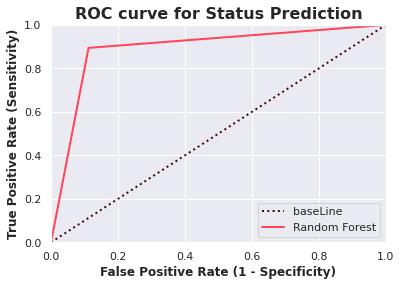

In [ ]:
sns.set(font_scale=1)
fpr_rf, tpr_rf, thresholds = metrics.roc_curve(y_test, rf.predict(X_test))
plt.plot([0, 1], [0, 1], linestyle=':',color='#450414', linewidth=2)
plt.plot(fpr_rf, tpr_rf,linestyle='-',color='#ff4557', linewidth=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.rcParams['font.size'] = 12
plt.legend(['baseLine', 'Random Forest'])
plt.title('ROC curve for Status Prediction',fontsize=16, weight='bold')
plt.xlabel('False Positive Rate (1 - Specificity)',weight='bold')
plt.ylabel('True Positive Rate (Sensitivity)',weight='bold')
plt.grid(True)

/usr/local/lib/python3.7/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_precision_recall_curve is deprecated; Function `plot_precision_recall_curve` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: PrecisionRecallDisplay.from_predictions or PrecisionRecallDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


Text(0.5, 1.0, 'Status Prediction: ')

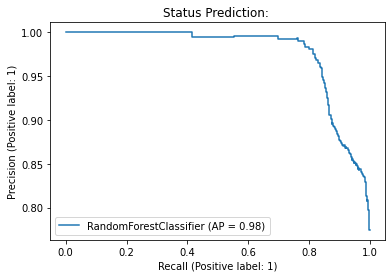

In [ ]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import plot_precision_recall_curve
from sklearn.preprocessing import MultiLabelBinarizer
import matplotlib.pyplot as plt
disp = plot_precision_recall_curve(rf, X_test, y_test)
disp.ax_.set_title('Status Prediction: ')

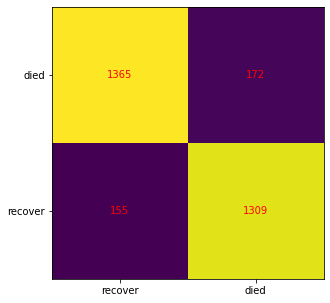

In [ ]:
 fig, ax = plt.subplots(figsize=(5, 5))
 ax.imshow(cm)
 ax.grid(False)
 ax.xaxis.set(ticks=(0, 1), ticklabels=('recover', 'died'))
 ax.yaxis.set(ticks=(0, 1), ticklabels=('died', 'recover'))
ax.set_ylim(1.5, -0.5)
 for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='red')
 plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.15, random_state=0)

In [ ]:
def evaluate(model, test_features, test_labels):
    predictions = model.predict(test_features)
    errors = abs(predictions - test_labels)
    mape = 100 * np.mean(errors / test_labels)
    accuracy = 100 - mape
    print('Model Performance')
    print('Average Error: {:0.4f} degrees.'.format(np.mean(errors)))
    print('Accuracy = {:0.2f}%.'.format(accuracy))

    return accuracy

In [ ]:
model = SVC(kernel='linear')
model.fit(X_train, y_train)

/usr/local/lib/python3.7/dist-packages/sklearn/utils/validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC(kernel='linear')

In [ ]:
predictions = model.predict(X_test)
print(predictions)

[1 1 1 ... 0 0 1]


In [ ]:
#percentage = model.score(X_test, y_test)

In [ ]:
from sklearn.metrics import confusion_matrix
#import scikitplot as skplt
xxxx=model.predict(X_test)
cm=confusion_matrix(y_test, model.predict(X_test))

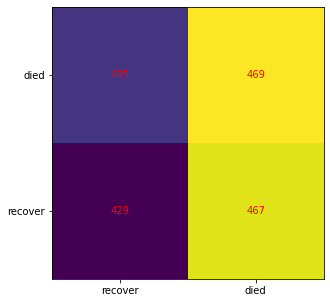

In [ ]:
 fig, ax = plt.subplots(figsize=(5, 5))
 ax.imshow(cm)
 ax.grid(False)
 ax.xaxis.set(ticks=(0, 1), ticklabels=('recover', 'died'))
 ax.yaxis.set(ticks=(0, 1), ticklabels=('died', 'recover'))
ax.set_ylim(1.5, -0.5)
 for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='red')
 plt.show()

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report

report_dict = classification_report(y_test, model.predict(X_test), output_dict=True)
pd.DataFrame(report_dict)

,0,1,accuracy,macro avg,weighted avg
precision,0.505631,0.515882,0.510827,0.510756,0.510810
recall,0.503928,0.517582,0.510827,0.510755,0.510827
f1-score,0.504778,0.516731,0.510827,0.510754,0.510817
support,891.000000,910.000000,0.510827,1801.000000,1801.000000


/usr/local/lib/python3.7/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_precision_recall_curve is deprecated; Function `plot_precision_recall_curve` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: PrecisionRecallDisplay.from_predictions or PrecisionRecallDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


Text(0.5, 1.0, 'Status Prediction: ')

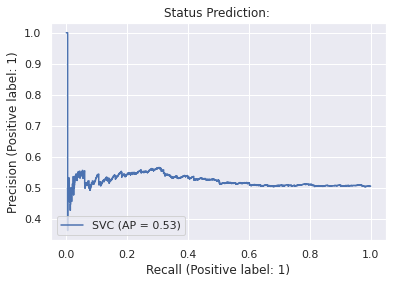

In [ ]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import plot_precision_recall_curve
from sklearn.preprocessing import MultiLabelBinarizer
import matplotlib.pyplot as plt
disp = plot_precision_recall_curve(model, X_test, y_test)
disp.ax_.set_title('Status Prediction: ')

In [ ]:
neigh = KNeighborsClassifier(n_neighbors=5)
neigh.fit(X_train, y_train)
base_accuracy = evaluate(neigh, X_test, y_test)

/usr/local/lib/python3.7/dist-packages/sklearn/neighbors/_classification.py:198: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Model Performance
Average Error: 0.5001 degrees.
Accuracy = nan%.


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:4: RuntimeWarning: divide by zero encountered in true_divide
  after removing the cwd from sys.path.
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:4: RuntimeWarning: invalid value encountered in true_divide
  after removing the cwd from sys.path.


In [ ]:
from sklearn.metrics import confusion_matrix
#import scikitplot as skplt
xxxx=neigh.predict(X_test)
cm=confusion_matrix(y_test, neigh.predict(X_test))

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report

report_dict = classification_report(y_test, neigh.predict(X_test), output_dict=True)
pd.DataFrame(report_dict)

,0,1,accuracy,macro avg,weighted avg
precision,0.823256,0.791489,0.806667,0.807373,0.807443
recall,0.783186,0.830357,0.806667,0.806771,0.806667
f1-score,0.802721,0.810458,0.806667,0.806589,0.806572
support,904.000000,896.000000,0.806667,1800.000000,1800.000000


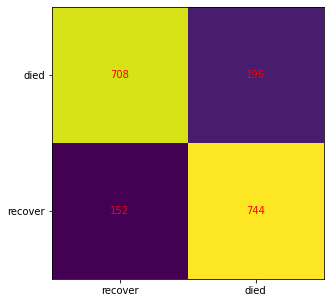

In [ ]:
 fig, ax = plt.subplots(figsize=(5, 5))
 ax.imshow(cm)
 ax.grid(False)
 ax.xaxis.set(ticks=(0, 1), ticklabels=('recover', 'died'))
 ax.yaxis.set(ticks=(0, 1), ticklabels=('died', 'recover'))
ax.set_ylim(1.5, -0.5)
 for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='red')
 plt.show()

/usr/local/lib/python3.7/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_precision_recall_curve is deprecated; Function `plot_precision_recall_curve` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: PrecisionRecallDisplay.from_predictions or PrecisionRecallDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


Text(0.5, 1.0, 'Status Prediction: ')

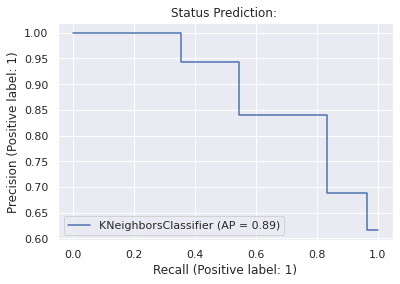

In [ ]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import plot_precision_recall_curve
from sklearn.preprocessing import MultiLabelBinarizer
import matplotlib.pyplot as plt
disp = plot_precision_recall_curve(neigh, X_test, y_test)
disp.ax_.set_title('Status Prediction: ')

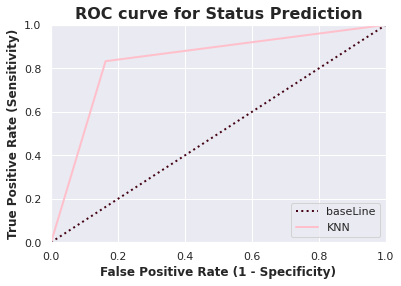

In [ ]:
sns.set(font_scale=1)
fpr_neigh, tpr_neigh, thresholds = metrics.roc_curve(y_test, neigh.predict(X_test))
plt.plot([0, 1], [0, 1], linestyle=':',color='#450414', linewidth=2)
plt.plot(fpr_neigh, tpr_neigh,linestyle='-',color='pink', linewidth=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.rcParams['font.size'] = 12
plt.legend(['baseLine', 'KNN'])
plt.title('ROC curve for Status Prediction',fontsize=16, weight='bold')
plt.xlabel('False Positive Rate (1 - Specificity)',weight='bold')
plt.ylabel('True Positive Rate (Sensitivity)',weight='bold')
plt.grid(True)

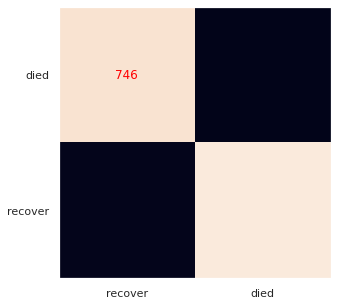

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(cm)
ax.grid(False)
ax.xaxis.set(ticks=(0, 1), ticklabels=('recover', 'died'))
ax.yaxis.set(ticks=(0, 1), ticklabels=('died', 'recover'))
ax.set_ylim(1.5, -0.5)
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='red')
        plt.show()

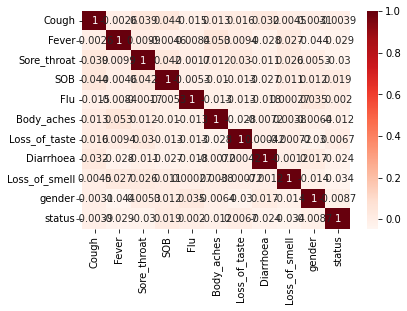

In [ ]:
import os
import seaborn as sns
data[['Cough','Fever','Sore_throat','SOB', 'Flu',	'Body_aches',	'Loss_of_taste',	'Diarrhoea',	'Loss_of_smell', 'gender', 'status']].corr()

#plot the correlation matrix of salary, balance and age in data dataframe.
sns.heatmap(data[['Cough','Fever','Sore_throat','SOB', 'Flu',	'Body_aches',	'Loss_of_taste',	'Diarrhoea',	'Loss_of_smell'	,'gender', 'status']].corr(), annot=True, cmap = 'Reds')
plt.show()

In [ ]:
!pip install tensorflow
!pip install shap
!pip install seaborn

In [ ]:
!pip install ggplot

In [ ]:
%matplotlib inline

import pandas as pd
import numpy as np
import math

import seaborn as sns
import matplotlib.pyplot as plt

import shap
shap.initjs()

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(tf.__version__)

2.7.0


In [ ]:
from sklearn.ensemble import RandomForestRegressor
Y = data['wave']
X =  data[['Fever', 'Cough', 'Sore_throat' , 'SOB' , 'Body_aches']]
# Split the data into train and test data:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2)
# Build the model with the random forest regression algorithm:
model = RandomForestRegressor(max_depth=6, random_state=0, n_estimators=10)
model.fit(X_train, Y_train)

RandomForestRegressor(max_depth=6, n_estimators=10, random_state=0)

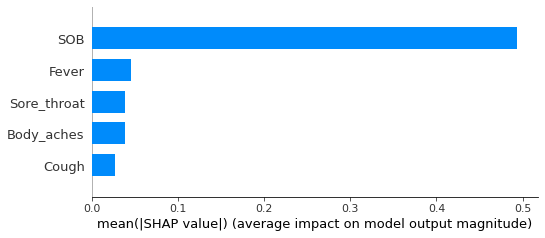

In [ ]:
import shap
shap_values = shap.TreeExplainer(model).shap_values(X_train)
shap.summary_plot(shap_values, X_train, plot_type="bar")

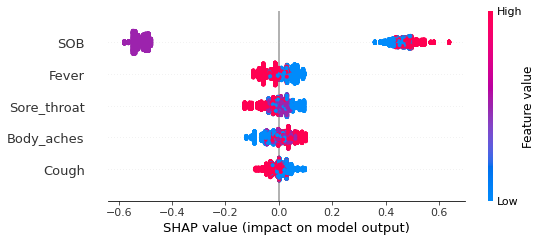

In [ ]:
shap.summary_plot(shap_values, X_train)

In [ ]:
clR = LogisticRegression(random_state=0).fit(X_train, y_train)
pred= clR.predict(X_test)
accuracy_score(y_test, pred)

/usr/local/lib/python3.7/dist-packages/sklearn/utils/validation.py:985: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.5124930594114381

In [ ]:
from sklearn.metrics import confusion_matrix
#import scikitplot as skplt
xxxx=clR.predict(X_test)
cm=confusion_matrix(y_test, clR.predict(X_test))

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report

report_dict = classification_report(y_test, clR.predict(X_test), output_dict=True)
pd.DataFrame(report_dict)

,0,1,accuracy,macro avg,weighted avg
precision,0.507345,0.517467,0.512493,0.512406,0.512459
recall,0.503928,0.520879,0.512493,0.512404,0.512493
f1-score,0.505631,0.519168,0.512493,0.512399,0.512471
support,891.000000,910.000000,0.512493,1801.000000,1801.000000


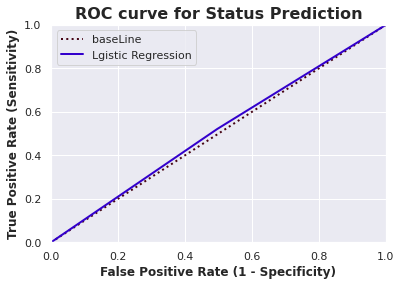

In [ ]:
sns.set(font_scale=1)
fpr_clR, tpr_clR, thresholds = metrics.roc_curve(y_test, clR.predict(X_test))
plt.plot([0, 1], [0, 1], linestyle=':',color='#450414', linewidth=2)
plt.plot(fpr_clR, tpr_clR,linestyle='-',color='#3300cc', linewidth=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.rcParams['font.size'] = 12
plt.legend(['baseLine', 'Lgistic Regression'])
plt.title('ROC curve for Status Prediction',fontsize=16, weight='bold')
plt.xlabel('False Positive Rate (1 - Specificity)',weight='bold')
plt.ylabel('True Positive Rate (Sensitivity)',weight='bold')
plt.grid(True)

In [ ]:
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
#from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.svm import SVC
clf = SVC(gamma='auto').fit(X_train, y_train)
pred= clf.predict(X_test)
accuracy_score(y_test, pred)

/usr/local/lib/python3.7/dist-packages/sklearn/utils/validation.py:985: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.5857856746252083

In [ ]:
from sklearn.metrics import confusion_matrix
#import scikitplot as skplt
xxxx=clf.predict(X_test)
cm=confusion_matrix(y_test, clf.predict(X_test))

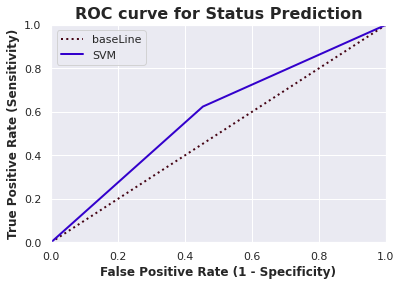

In [ ]:
sns.set(font_scale=1)
fpr_clf, tpr_clf, thresholds = metrics.roc_curve(y_test, clf.predict(X_test))
plt.plot([0, 1], [0, 1], linestyle=':',color='#450414', linewidth=2)
plt.plot(fpr_clf, tpr_clf,linestyle='-',color='#3300cc', linewidth=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.rcParams['font.size'] = 12
plt.legend(['baseLine', 'SVM'])
plt.title('ROC curve for Status Prediction',fontsize=16, weight='bold')
plt.xlabel('False Positive Rate (1 - Specificity)',weight='bold')
plt.ylabel('True Positive Rate (Sensitivity)',weight='bold')
plt.grid(True)

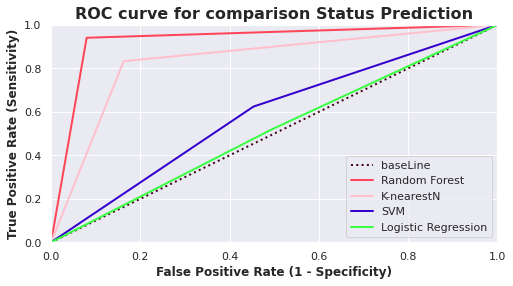

In [ ]:
sns.set(font_scale=1)
fpr_rf, tpr_rf, thresholds = metrics.roc_curve(y_test, rf.predict(X_test))
fpr_neigh, tpr_neigh, thresholds = metrics.roc_curve(y_test, neigh.predict(X_test))
fpr_clf, tpr_clf, thresholds = metrics.roc_curve(y_test, clf.predict(X_test))
fpr_clR, tpr_clR, thresholds = metrics.roc_curve(y_test, clR.predict(X_test))
plt.figure(figsize =(8, 4))
plt.plot([0, 1], [0, 1], linestyle=':',color='#450414', linewidth=2)
plt.plot(fpr_rf, tpr_rf,linestyle='-',color='#ff4557', linewidth=2)
plt.plot(fpr_neigh, tpr_neigh,linestyle='-',color='pink', linewidth=2)
plt.plot(fpr_clf, tpr_clf,linestyle='-',color='#3300cc', linewidth=2)
plt.plot(fpr_clR, tpr_clR,linestyle='-',color='#3aff44', linewidth=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.rcParams['font.size'] = 12
plt.legend(['baseLine', 'Random Forest','K-nearestN', 'SVM' ,'Logistic Regression'])
plt.title('ROC curve for comparison Status Prediction',fontsize=16, weight='bold')
plt.xlabel('False Positive Rate (1 - Specificity)',weight='bold')
plt.ylabel('True Positive Rate (Sensitivity)',weight='bold')
plt.grid(True)